# Flood Risk Monitoring and Mitigation

This lesson maps flood susceptibility for an approximate Niger River
floodplain using terrain, rainfall, radar, surface-water, river-distance,
and land-cover predictors.

**Learning objectives**

- distinguish static susceptibility from event-specific flood signals;
- configure pre-flood and post-flood observation windows;
- interpret four flood-risk classes;
- use SHAP values to identify dominant model drivers.


## 1. Prepare the notebook session

This cell imports the tools used throughout the lesson and loads configuration
from a local `.env` file. The Earth Engine project identifier is configuration,
not analysis data, so it is kept outside the notebook.

Before running the notebook:

1. copy `.env.example` to `.env`;
2. replace the placeholder with your Google Earth Engine project ID;
3. run `earthengine authenticate` once in a terminal;
4. select the **Climate Change Workflows** kernel.

The `%matplotlib inline` backend renders figures directly below each plotting cell.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

WORKSPACE = Path.cwd()
if not (WORKSPACE / ".venv").exists() and (WORKSPACE.parent / ".venv").exists():
    WORKSPACE = WORKSPACE.parent

load_dotenv(WORKSPACE / ".env")
GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError("Create .env from .env.example and set GEE_PROJECT.")

OUTPUT_DIR = WORKSPACE / "outputs"
REPORT_DIR = WORKSPACE / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Workspace:", WORKSPACE)
print("Earth Engine project configured:", bool(GEE_PROJECT))


Workspace: /home/odero-george/workspace/climate-change-workflows
Earth Engine project configured: True


## 2. Inspect the package registry

The registry is the package's catalogue of supported analyses. It documents the
recommended date range, dependent variable, input variables, and selectable models.
Inspecting it before running an analysis helps us choose scientifically sensible
parameters instead of treating the model as a black box.


In [2]:
info = USE_CASE_REGISTRY["flood"]
print(info.name)
print("\nPurpose:", info.description)
print("\nPredicted variable:", info.dependent_variable)
print("\nDate guidance:", info.date_guidance)
print("\nAvailable models:")
for option in info.model_options:
    marker = " (recommended)" if option.recommended else ""
    print(f"  - {option.id}: {option.label}{marker} — {option.note}")


Flood Risk Monitoring & Mitigation

Purpose: This tool analyses terrain, rainfall patterns, and satellite radar imagery to identify which areas are at risk of flooding and how severe that flooding is likely to be. It produces a risk map showing low, medium, high, and very high risk zones.

Predicted variable: Flood risk class (Low / Medium / High / Very High)

Date guidance: Select a rainy season period for best results (e.g., March–May or Oct–Dec)

Available models:
  - rf: Random Forest (recommended) — Fastest · most interpretable
  - xgboost: XGBoost — Higher accuracy · longer run
  - ensemble: Ensemble (RF + XGBoost) — Best overall · slowest


## 3. Mathematical/Scientific model

Random Forest and XGBoost estimate class probabilities from a feature
vector $\mathbf{x}$ containing terrain and event indicators. For the
ensemble, the package combines model predictions conceptually as:

$$
\hat{p}_{\mathrm{ens}}(\mathbf{x})
= \frac{\hat{p}_{\mathrm{RF}}(\mathbf{x})
+ \hat{p}_{\mathrm{XGB}}(\mathbf{x})}{2}
$$

Risk classes are derived from probability intervals:

$$
C(\hat p)=
\begin{cases}
\text{Low}, & \hat p < 0.25\\
\text{Medium}, & 0.25 \le \hat p < 0.50\\
\text{High}, & 0.50 \le \hat p < 0.75\\
\text{Very High}, & \hat p \ge 0.75
\end{cases}
$$

Sentinel-1 change captures the difference between post-event and pre-event
radar backscatter, while rainfall windows represent immediate hydrological forcing.

## 4. Define the event and AOI

Flood studies need more than a general start and end date. We define separate
windows for baseline SAR, flood-period SAR, 7-day rainfall, 30-day rainfall,
and Sentinel-2 surface water. These dates should match the event being studied.


In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [1.80, 13.20], [2.60, 13.20], [2.60, 13.80],
        [1.80, 13.80], [1.80, 13.20],
    ]],
}

analysis_args = {
    "module": "flood",
    "aoi_geojson": aoi,
    "start_date": "2022-01-01",
    "end_date": "2023-01-31",
    "country": "Niger",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "ensemble",
        "flood_event": "Niger River flood pulse, 2022",
        "pre_flood_start": "2022-05-01",
        "pre_flood_end": "2022-07-31",
        "post_flood_start": "2022-10-01",
        "post_flood_end": "2023-01-31",
        "rain_7d_start": "2022-08-18",
        "rain_7d_end": "2022-08-25",
        "rain_30d_start": "2022-08-01",
        "rain_30d_end": "2022-08-31",
        "mndwi_start": "2022-10-01",
        "mndwi_end": "2023-01-31",
        "flood_label_start": "2021-01-01",
        "flood_label_end": "2021-12-31",
        "n_pixels": 3000,
        "scale": 90,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "niger_flood_2022",
    },
}
analysis_args

{'module': 'flood',
 'aoi_geojson': {'type': 'Polygon',
  'coordinates': [[[1.8, 13.2],
    [2.6, 13.2],
    [2.6, 13.8],
    [1.8, 13.8],
    [1.8, 13.2]]]},
 'start_date': '2022-01-01',
 'end_date': '2023-01-31',
 'country': 'Niger',
 'gee_project': 'parallelprocessing-433914',
 'extra_params': {'model_type': 'ensemble',
  'flood_event': 'Niger River flood pulse, 2022',
  'pre_flood_start': '2022-05-01',
  'pre_flood_end': '2022-07-31',
  'post_flood_start': '2022-10-01',
  'post_flood_end': '2023-01-31',
  'rain_7d_start': '2022-08-18',
  'rain_7d_end': '2022-08-25',
  'rain_30d_start': '2022-08-01',
  'rain_30d_end': '2022-08-31',
  'mndwi_start': '2022-10-01',
  'mndwi_end': '2023-01-31',
  'flood_label_start': '2021-01-01',
  'flood_label_end': '2021-12-31',
  'n_pixels': 3000,
  'scale': 90,
  'output_dir': '/home/odero-george/workspace/climate-change-workflows/outputs',
  'prefix': 'niger_flood_2022'}}

## 5. Run the analysis

`run_analysis` is asynchronous because data retrieval and model execution may be
long-running operations. Jupyter supports top-level `await`, so no explicit event
loop is required here.

The first run may take several minutes. Runtime depends on AOI size, temporal
coverage, Earth Engine quota, sampling resolution, and model choice.


In [4]:
output = await run_analysis(**analysis_args)
print("Analysis complete:", output.module)

2026-07-03 15:44:41,370 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/odero-george/workspace/climate-change-workflows/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41127 instead
  warnings.warn(
2026-07-03 15:44:41,403 - distributed.scheduler - INFO - State start
2026-07-03 15:44:41,409 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:36779
2026-07-03 15:44:41,410 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:41127/status
2026-07-03 15:44:41,411 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-07-03 15:44:41,432 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35673'
2026-07-03 15:44:41,436 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.

Analysis complete: flood


## 6. Inspect the common output contract

Every use case returns an `AnalysisOutput` object with the same top-level fields:

- `stats`: summary indicators suitable for dashboards and reports;
- `charts`: structured time-series and distribution data;
- `geojson`: spatial features for a web map or GIS;
- `raster_path`: generated Cloud-Optimized GeoTIFF path(s), when available;
- `shap`: feature-importance information for supported models;
- `metadata`: model, period, country, and optional report information.

The internal keys of `stats` and `charts` remain specific to each scientific domain.


In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON feature count:", len(output.geojson.get("features", [])))
print("Chart payloads:", sorted(output.charts))
print("Metadata:", output.metadata)

pd.Series(output.stats, name="value").to_frame()

Module: flood
Raster output: {'flood_risk': '/home/odero-george/workspace/climate-change-workflows/outputs/niger_flood_2022_flood_risk.tif'}
GeoJSON feature count: 10
Chart payloads: ['model_performance', 'risk_distribution', 'shap', 'uncertainty']
Metadata: {'model': 'ensemble', 'country': 'Niger', 'start_date': '2022-01-01', 'end_date': '2023-01-31', 'raster': {'flood_risk': '/home/odero-george/workspace/climate-change-workflows/outputs/niger_flood_2022_flood_risk.tif'}, 'windows': {'pre_flood': {'start': '2022-05-01', 'end': '2022-07-31'}, 'post_flood': {'start': '2022-10-01', 'end': '2023-01-31'}, 'rainfall_7d': {'start': '2022-08-18', 'end': '2022-08-25'}, 'rainfall_30d': {'start': '2022-08-01', 'end': '2022-08-31'}, 'mndwi': {'start': '2022-10-01', 'end': '2023-01-31'}}}


,value
model_type,ensemble
n_pixels_sampled,45
flooded_pct,71.1
rf_cv_f1,0.661
rf_f1,0.8
rf_auc,0.3889
xgb_cv_f1,0.7785
xgb_f1,0.8
xgb_auc,0.3889
ensemble_f1,0.8


## 7. Visualize risk and model drivers

The risk chart summarizes the percentage of sampled pixels in each class.
SHAP values explain the magnitude of each feature's contribution:

$$
f(\mathbf{x}) = \phi_0 + \sum_{j=1}^{M}\phi_j
$$

where $\phi_0$ is the baseline model output and $\phi_j$ is the SHAP
contribution of feature $j$. Mean absolute SHAP values rank global importance
but do not by themselves show whether a feature raises or lowers risk.


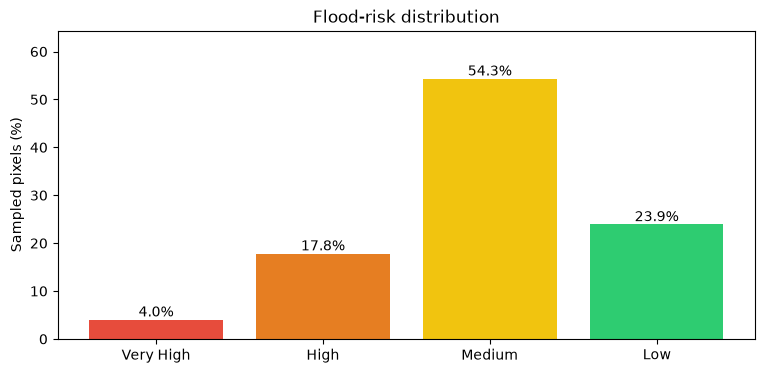

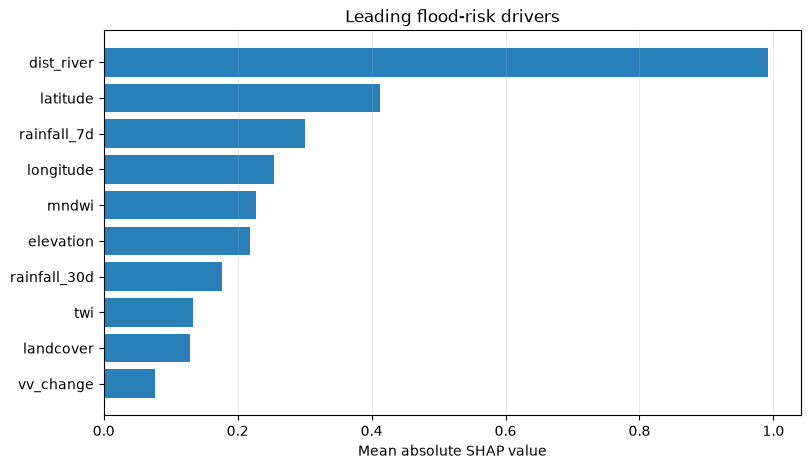

In [6]:
risk = output.charts.get("risk_distribution", {})
if risk.get("labels"):
    colors = risk.get("colors", ["#2ECC71", "#F1C40F", "#E67E22", "#C0392B"])
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(risk["labels"], risk["data"], color=colors)
    ax.bar_label(bars, fmt="%.1f%%")
    ax.set_ylabel("Sampled pixels (%)")
    ax.set_title("Flood-risk distribution")
    ax.set_ylim(0, max(risk["data"]) + 10)
    plt.show()

shap = output.shap or output.charts.get("shap", {})
if shap.get("features"):
    features = shap["features"][:10][::-1]
    values = shap["mean_abs_shap"][:10][::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(features, values, color="#2980B9")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_title("Leading flood-risk drivers")
    ax.grid(axis="x", alpha=0.25)
    plt.show()


## 8. Locate spatial artifacts

The analysis may produce GeoJSON features and one or more Cloud-Optimized GeoTIFF
files. GeoJSON is convenient for APIs and interactive maps, while COGs preserve
continuous raster coverage for GIS software and cloud-native access.

The following cell reports the artifacts without attempting to display a large
raster inside the notebook.


In [7]:
print("GeoJSON type:", output.geojson.get("type"))
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Raster path(s):", output.raster_path)

if output.raster_path:
    paths = (
        output.raster_path.values()
        if isinstance(output.raster_path, dict)
        else [output.raster_path]
    )
    for path in paths:
        artifact = Path(path)
        print(f"{artifact.name}: exists={artifact.exists()}")


GeoJSON type: FeatureCollection
GeoJSON features: 10
Raster path(s): {'flood_risk': '/home/odero-george/workspace/climate-change-workflows/outputs/niger_flood_2022_flood_risk.tif'}
niger_flood_2022_flood_risk.tif: exists=True


## 9. Optional: generate a PDF report

Setting `GENERATE_REPORT` to `True` reruns the same request and asks the package to
assemble a PDF containing metadata, statistics, charts, interpretation text, and
available map content. Keep it `False` during exploration to avoid an unnecessary
second model run.


In [8]:
GENERATE_REPORT = True

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change-workflows/reports/flood_20260703_124539.pdf
